# 新易盛：笔记经验与原则的三年回溯检验

## tl;dr

组合模型尚未证明优于简单对照。以下单元从冻结行情重新计算，并展示完整来源与回测结果。详细解释见同目录 report.md。

## Context & Methods

股票300502；实际复权评估2023-09-18至2026-09-15，未来1–4个交易日；最近一年留出。所有案例后续结果必须早于当前10日观察窗口。

### Key Assumptions

BOLL20/2总体标准差、SMA5/10/20。笔记增量外推不是收盘价预测；当前笔记版本回看过去是回溯研究，不是实时前瞻证明。只有一只用户指定股票，不能泛化。

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
assert (ROOT / 'backtest.py').exists(), '从本笔记所在目录运行'
sys.path.insert(0, str(ROOT))
from validate_inputs import validate
from backtest import run_backtest
from evaluate_principles import evaluate
from render_report import render
frame, quality = validate()
quality

{'sourceHashesVerified': 16,
 'rawSourceCrosscheck': {'overlapSessions': 1023,
  'maxPriceDifferenceCNY': 0.0,
  'priceMismatchesOver0011': 0,
  'maxVolumeDifferenceShares': 50.0,
  'volumeMismatchesOver100Shares': 0},
 'coverage': {'warmupFirst': '2022-01-04',
  'lastVerifiedAdjustedSession': '2026-09-15',
  'lastRawSession': '2026-09-16',
  'evaluationFirst': '2023-09-18',
  'evaluationLast': '2026-09-15',
  'evaluationSessions': 725,
  'missingVsBenchmarkCalendar': [],
  'nonpositiveVolumeSessions': []},
 'corporateActionCandidates': [{'day': '2025-05-28',
   'rawReturn': -0.245340230090074,
   'adjustedReturn': 0.061565804674309055},
  {'day': '2026-06-11',
   'rawReturn': -0.31909385113268607,
   'adjustedReturn': -0.04549677719063938}],
 'caveats': ['腾讯复权日线最后日期比未复权日线滞后，评估截止共同已验证日期，不拼接未经核验的复权行情。',
  '前复权是本次下载的数据版本，不是每个历史时点独立保存的版本。',
  '原始成交量不随复权股价缩放，除权事件附近的量比解释应谨慎。',
  '腾讯和新浪可能共享上游交易所数据；交叉一致性不等于两个独立交易所来源。']}

## Analysis

### 1. 重算所有预测原点

固定方法，不按留出结果调整参数。

In [2]:
forecasts, indicators = run_backtest(frame)
evaluate()
summary = json.loads((ROOT / 'results/summary.json').read_text(encoding='utf-8'))
price_table = pd.DataFrame(summary['price'])
display(price_table.query("partition == 'holdout' and horizon in [3,4]")[['model','horizon','origins','close_mape','direction_accuracy_pct']])

{
  "targets": [
    {
      "context": "all",
      "partition": "holdout",
      "model": "note_delta1",
      "horizon": 3,
      "kind": "buy_reference",
      "origins": 239,
      "touch_pct": 33.054393305439326,
      "extreme_within_1pct_pct": 11.715481171548117,
      "extreme_mape": 6.703825619945991
    },
    {
      "context": "all",
      "partition": "holdout",
      "model": "note_delta1",
      "horizon": 3,
      "kind": "sell_reference",
      "origins": 239,
      "touch_pct": 11.715481171548117,
      "extreme_within_1pct_pct": 5.439330543933055,
      "extreme_mape": 11.001348115668227
    },
    {
      "context": "all",
      "partition": "holdout",
      "model": "note_delta2",
      "horizon": 3,
      "kind": "buy_reference",
      "origins": 239,
      "touch_pct": 32.63598326359833,
      "extreme_within_1pct_pct": 11.715481171548117,
      "extreme_mape": 6.828988359779377
    },
    {
      "context": "all",
      "partition": "holdout",
      "model": "n

,model,horizon,origins,close_mape,direction_accuracy_pct
34,baseline_v1,3,239,6.200984,46.443515
35,baseline_v1,4,238,7.407825,44.957983
38,last_close,3,239,5.800526,0.836820
39,last_close,4,238,6.673353,0.840336
42,note_analog,3,239,5.901404,51.464435
43,note_analog,4,238,6.845901,52.941176
46,price_analog,3,239,5.886070,52.301255
47,price_analog,4,238,6.742171,52.941176


### 2. 检查对照差异及不确定性

改善为正才代表比对照误差小；20日时间块重采样处理重叠预测的相关性。

In [3]:
comparison = pd.DataFrame(summary['pairedBlockBootstrap'])
display(comparison.query("partition == 'holdout' and horizon in [3,4]"))

,partition,horizon,model,improvement_mape_pp,ci95_mape_pp
40,holdout,3,baseline_v1,-0.400457,"[-0.6545076155477163, -0.13292228908986456]"
41,holdout,3,price_analog,-0.085544,"[-0.27425584496473837, 0.09197944928524214]"
42,holdout,3,note_analog,-0.100878,"[-0.26409633479295264, 0.06178569901423032]"
43,holdout,3,note_analog_vs_price_analog,-0.015334,"[-0.14701849740764883, 0.13604021983603437]"
44,holdout,4,baseline_v1,-0.734472,"[-1.154332018108385, -0.302088224638986]"
45,holdout,4,price_analog,-0.068818,"[-0.3733307145432488, 0.21861108670819915]"
46,holdout,4,note_analog,-0.172548,"[-0.48172682740593187, 0.12749547846746787]"
47,holdout,4,note_analog_vs_price_analog,-0.103729,"[-0.2854047502160908, 0.07779691686165346]"


## Results

### 3. 价格、参数及参考位

图表来自上述重算的账本；低参数误差不等于交易胜率。

{"figures": 5, "report": "E:\\Code\\Stock\\research\\2026-09-16-xinyisheng\\report.md"}


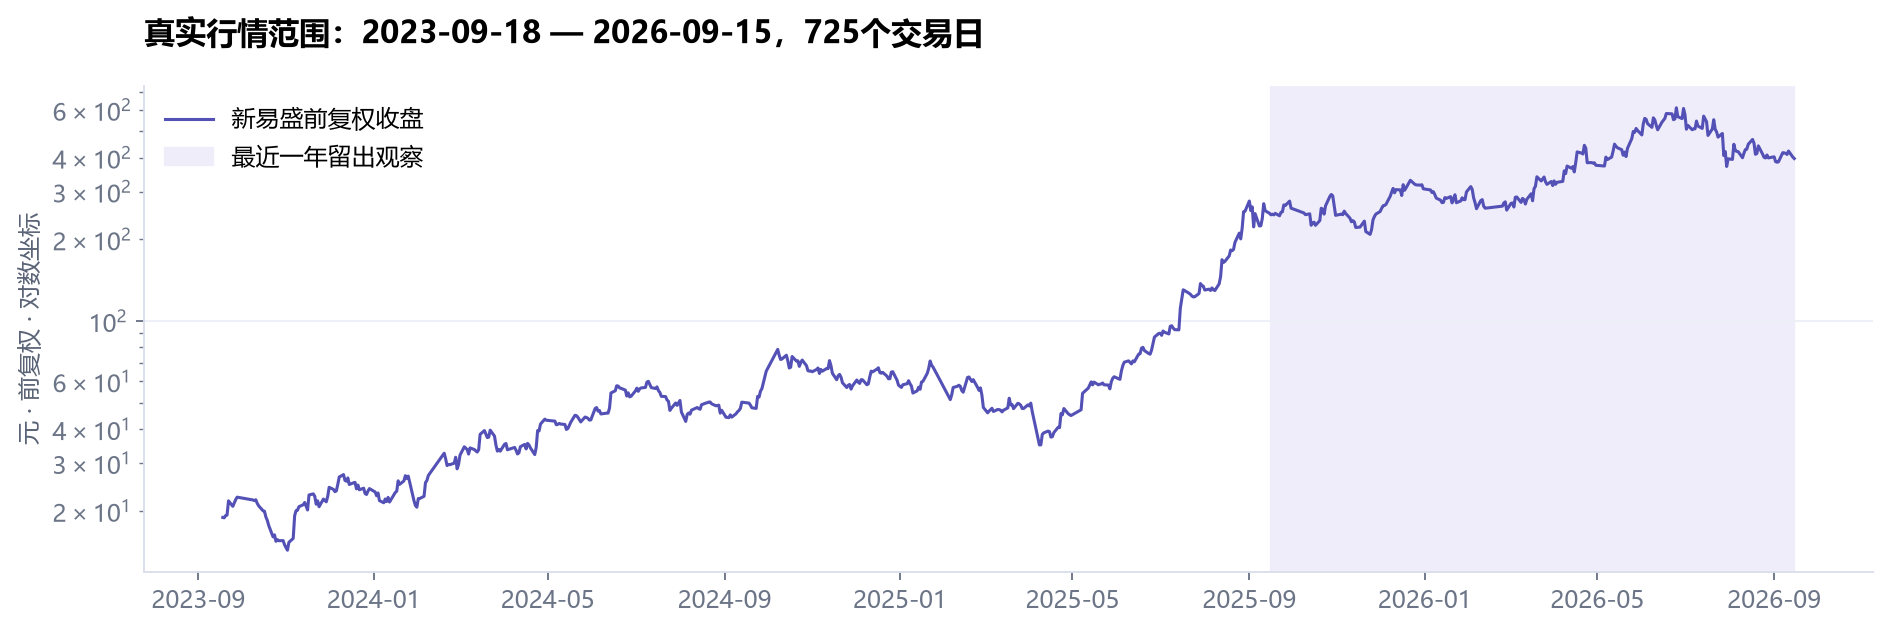

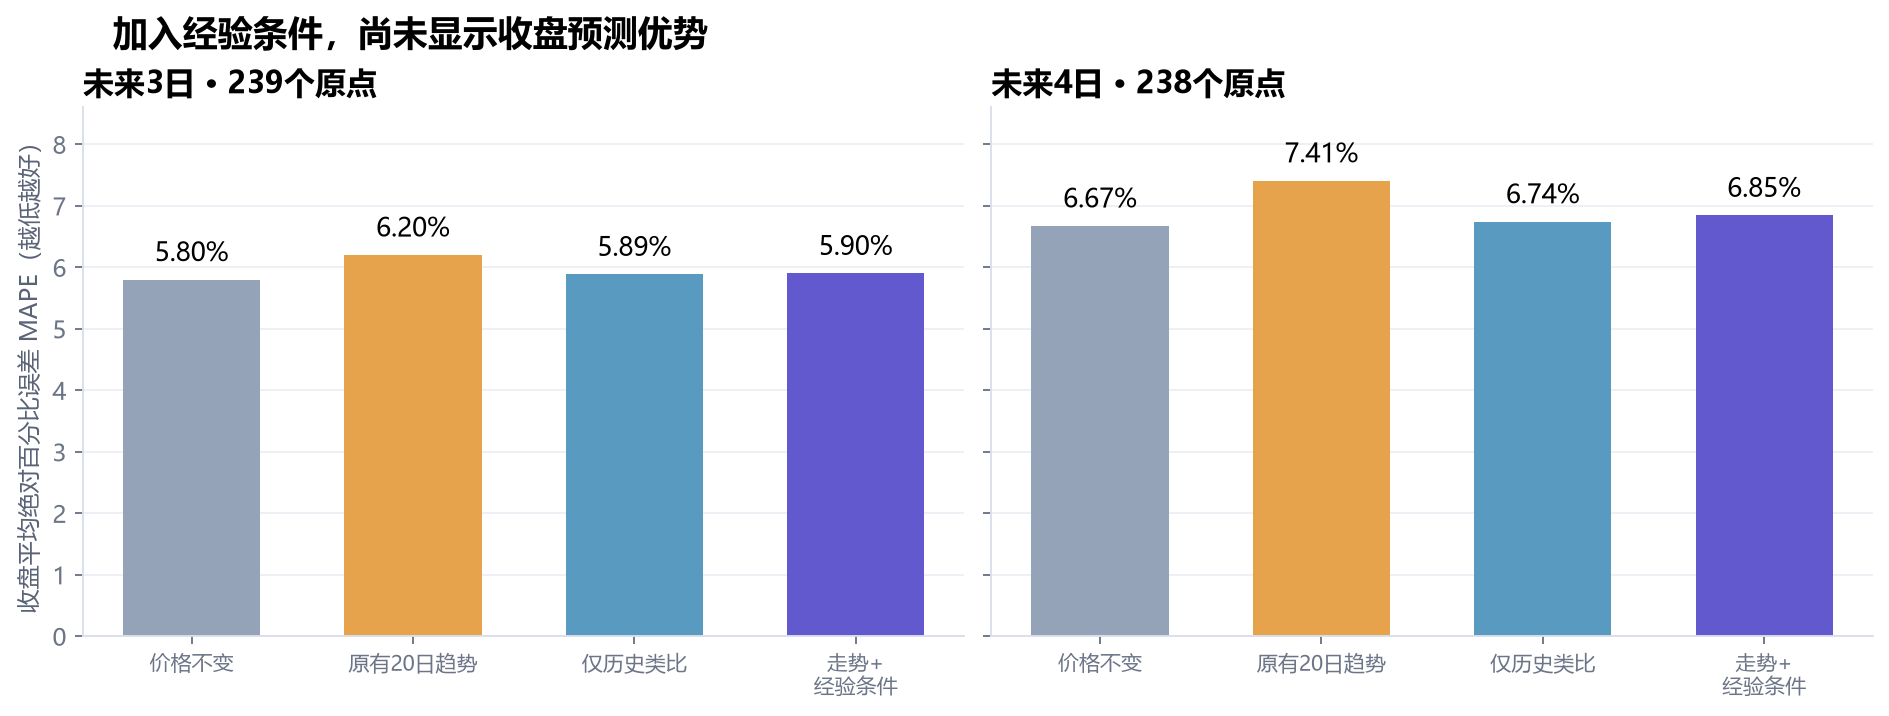

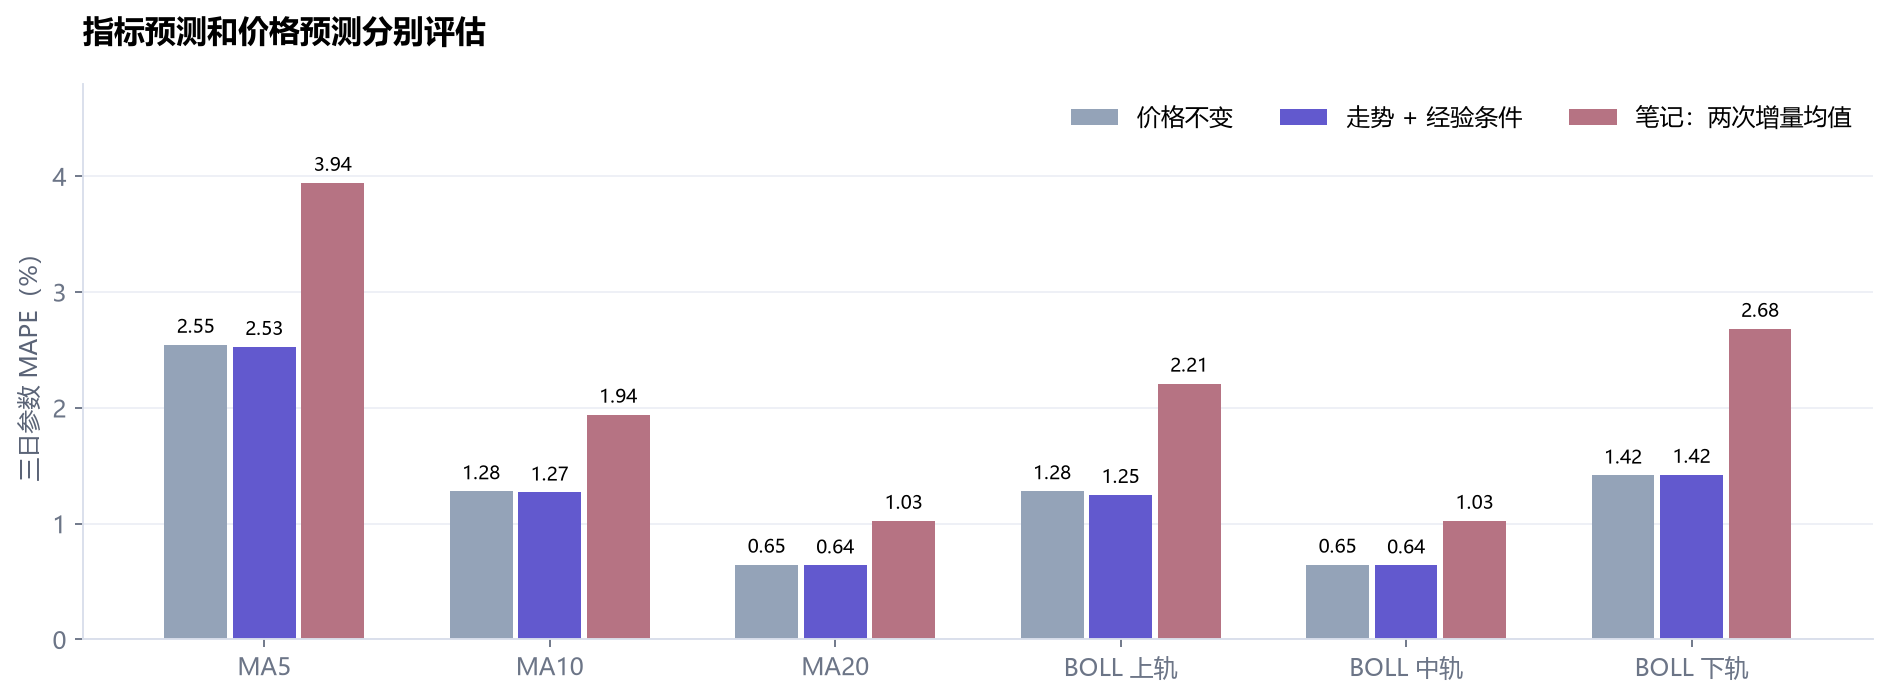

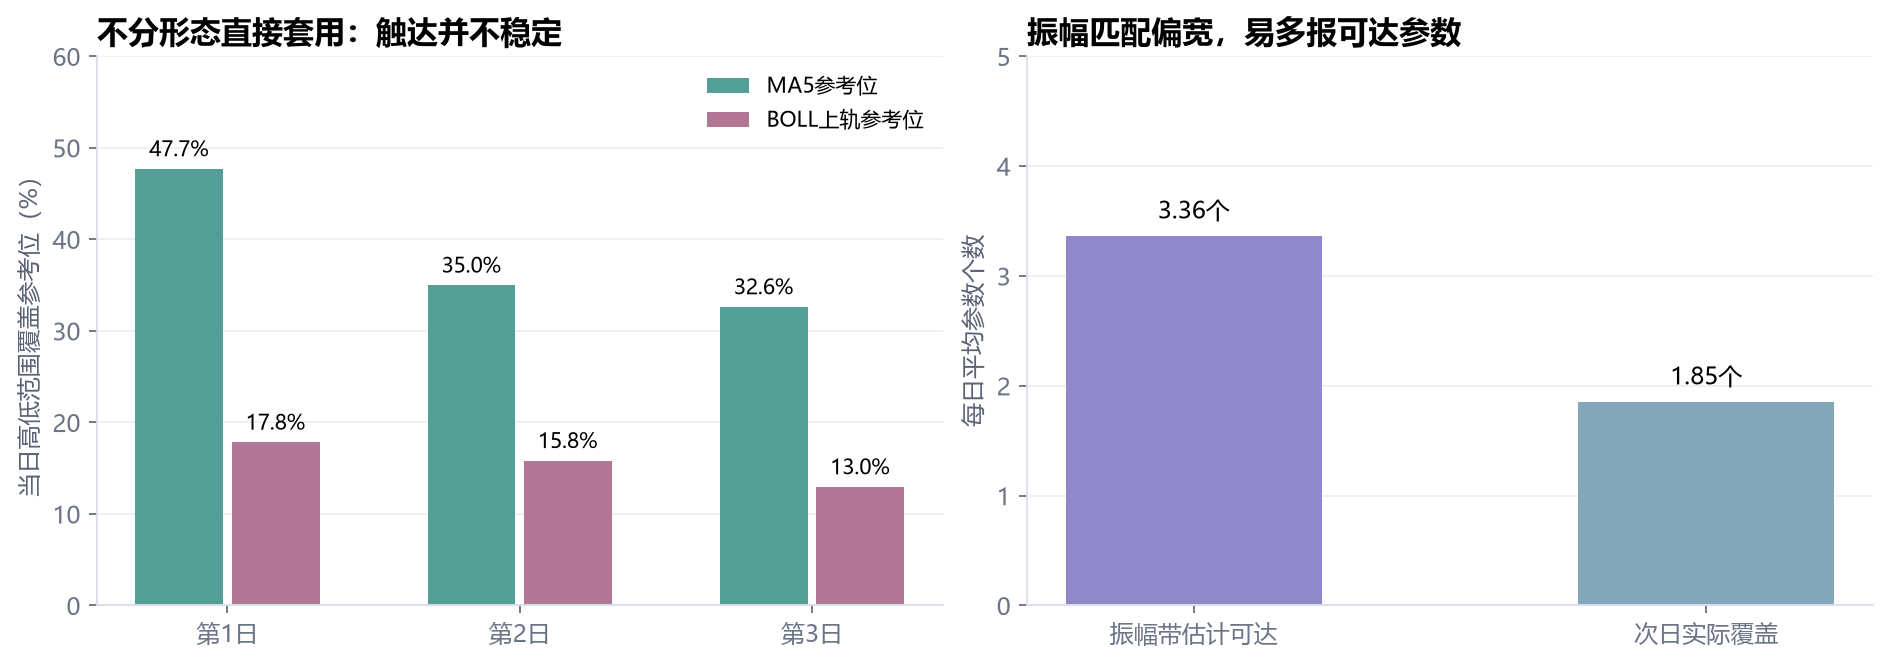

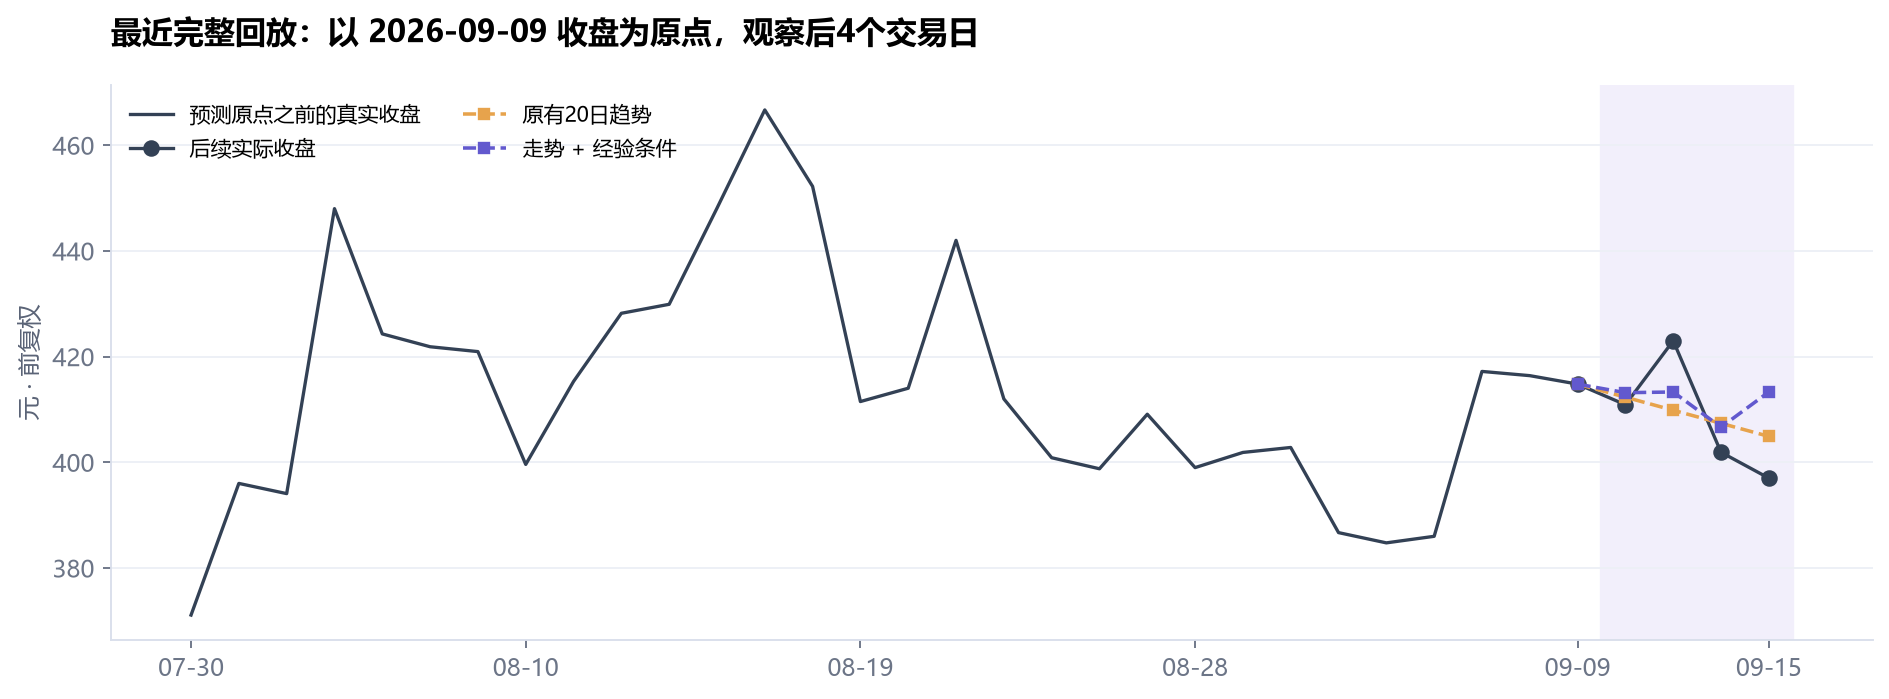

In [4]:
render()
for name in ['01-history-and-split.png','02-price-errors.png','03-indicator-errors.png','05-manual-reference-check.png','04-latest-complete-replay.png']:
    display(Image(filename=str(ROOT / 'figures' / name)))

## Takeaways

确认经验的含义、补齐情境标签和保留反例，比无休止训练Agent更优先。当前组合没有稳定收盘预测增益；新定义需要多股与未来时段验证。手动提示应保留类型、股票、有效期和版本；确认解释不得自动启用交易。